# Sistem Rekomendasi Lagu Spotify 🎵

Notebook ini membangun sistem rekomendasi musik berdasarkan data Spotify track dengan dua pendekatan utama:

1. **Content-Based Filtering**: merekomendasikan lagu yang mirip berdasarkan fitur seperti danceability, energy, valence, dll.
2. **Collaborative Filtering** *(jika tersedia)*: merekomendasikan lagu berdasarkan perilaku pengguna.

## 🎯 Tujuan
- Membuat sistem rekomendasi lagu yang dipersonalisasi.
- Memberikan saran lagu baru yang kemungkinan disukai oleh pengguna.
- Menunjukkan bagaimana dua pendekatan berbeda bekerja pada dataset Spotify.

Dataset: [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)


In [6]:
!pip install numpy==1.24.4

In [7]:
!pip install scikit-surprise

install scikit_surprise

# Import

In [8]:
# Import library untuk analisis data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Untuk machine learning dan preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Untuk menampilkan semua kolom
pd.set_option('display.max_columns', None)

import semua library

# Load Data

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/-spotify-tracks-dataset


download dataset menggunakan path kaggle hub

In [10]:
print(os.listdir(path))

['dataset.csv']


melihat list dataset yang sudah di download

In [11]:
tracks_file_path = os.path.join(path, 'dataset.csv')
df = pd.read_csv(tracks_file_path)

mengambil dataset dan menginisiasi dataset menjadi df

In [12]:
# Ambil sampel 20.000 baris secara acak
df = df.sample(n=20000, random_state=42).reset_index(drop=True)
print("Ukuran dataset setelah disampling:", df.shape)

Ukuran dataset setelah disampling: (20000, 21)


mengambil 20000 sample dataset untuk meminimalisir running time

In [13]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,113186,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50,440247,False,0.369,0.598,7,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
1,42819,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11,93933,False,0.171,0.997,7,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
2,59311,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0,213578,False,0.173,0.803,9,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
3,91368,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0,151387,False,0.683,0.511,6,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
4,61000,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,57,236293,False,0.555,0.941,9,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


melihat 5 data teratas

# Data Understanding

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        20000 non-null  int64  
 1   track_id          20000 non-null  object 
 2   artists           19999 non-null  object 
 3   album_name        19999 non-null  object 
 4   track_name        19999 non-null  object 
 5   popularity        20000 non-null  int64  
 6   duration_ms       20000 non-null  int64  
 7   explicit          20000 non-null  bool   
 8   danceability      20000 non-null  float64
 9   energy            20000 non-null  float64
 10  key               20000 non-null  int64  
 11  loudness          20000 non-null  float64
 12  mode              20000 non-null  int64  
 13  speechiness       20000 non-null  float64
 14  acousticness      20000 non-null  float64
 15  instrumentalness  20000 non-null  float64
 16  liveness          20000 non-null  float6

terdapat 20 kolom variabel yang memiliki kurang lebih 20000 sample yang memiliki tipe beragam

In [15]:
# Menampilkan semua kolom dan tipe data
df.columns, df.dtypes

(Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
        'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
        'key', 'loudness', 'mode', 'speechiness', 'acousticness',
        'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
        'track_genre'],
       dtype='object'),
 Unnamed: 0            int64
 track_id             object
 artists              object
 album_name           object
 track_name           object
 popularity            int64
 duration_ms           int64
 explicit               bool
 danceability        float64
 energy              float64
 key                   int64
 loudness            float64
 mode                  int64
 speechiness         float64
 acousticness        float64
 instrumentalness    float64
 liveness            float64
 valence             float64
 tempo               float64
 time_signature        int64
 track_genre          object
 dtype: object)

Cell ini digunakan untuk menampilkan seluruh kolom beserta tipe datanya pada dataset df, yang membantu dalam memahami struktur data sebelum dilakukan pemrosesan atau pemodelan. Informasi ini penting untuk menentukan kolom mana yang bersifat numerik (untuk filtering), kategorik, atau tidak relevan.

Penjelasan Variabel Penting:
- track_id, track_name, artists: identitas lagu.
- popularity, duration_ms, explicit: informasi umum lagu.
- danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo: fitur audio numerik, berguna untuk content-based filtering.
- track_genre: kategori genre lagu.
- Unnamed: 0: kolom indeks hasil import, sebaiknya dihapus.

In [16]:
# Menghapus kolom indeks duplikat (jika ada)
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

menghapus tabel Unnamed: 0

In [17]:
# Cek nilai kosong
missing_summary = df.isnull().sum()
print("Jumlah nilai kosong per kolom:\n", missing_summary)

# Jika ada kolom dengan missing value, drop baris tersebut
df_clean = df.dropna()

# Konfirmasi data setelah dibersihkan
print("\nSetelah menghapus missing value:")
print(df_clean.info())

Jumlah nilai kosong per kolom:
 track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Setelah menghapus missing value:
<class 'pandas.core.frame.DataFrame'>
Index: 19999 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          19999 non-null  object 
 1   artists           19999 non-null  object 
 2   album_name        19999 non-null  object 
 3   track_name        19999 non-null  object 
 4   popularity        19999 non-null  int64  
 5   duration_ms       19999 non-null  int64  
 

menghapus nilai null dan kembali melakukan pengecekan kepada df_clean

In [18]:
# Hapus duplikasi berdasarkan 'track_id' atau kombinasi unik track
before = df_clean.shape[0]
df_clean.drop_duplicates(subset=['track_id'], inplace=True)
after = df_clean.shape[0]

print(f"Duplikasi yang dihapus: {before - after}")

Duplikasi yang dihapus: 1039


<ipython-input-18-0ed9a1e95803>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop_duplicates(subset=['track_id'], inplace=True)


menghapus data duplikat yang berjumlah 1039

# Content-Based Filtering

In [19]:
# Pilih fitur audio numerik
audio_features = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

# Cek fitur yang tersedia
available_features = [col for col in audio_features if col in df_clean.columns]
print("Fitur yang tersedia untuk rekomendasi:", available_features)

# Normalisasi data numerik
scaler = StandardScaler()
feature_matrix = scaler.fit_transform(df_clean[available_features])

# Gabungkan kembali dengan info lagu
df_features = pd.DataFrame(feature_matrix, columns=available_features)
df_features['track_name'] = df_clean['track_name'].values
df_features['artists'] = df_clean['artists'].values

df_features.head()

Fitur yang tersedia untuk rekomendasi: ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_name,artists
0,-1.117736,-0.167486,0.476820,0.259860,0.754935,-0.508025,-0.936381,-0.507148,-0.205449,-1.627738,0.856016,No Other Name,Hillsong Worship
1,-2.247306,1.413433,0.476820,0.936550,0.754935,0.305402,-0.936082,2.078257,1.067974,-1.693477,-0.000498,Failed Organum,Internal Rot
2,-2.235896,0.644765,1.037889,-0.354896,-1.324618,0.546830,0.880625,-0.500983,-0.106289,-1.466831,-1.550035,"Save the Trees, Pt. 1",Zhoobin Askarieh;Ali Sasha
3,0.673601,-0.512198,0.196285,0.535873,0.754935,-0.531239,0.261895,-0.506512,-0.544681,0.479721,-0.406721,Merry Christmas,Bryan Adams
4,-0.056625,1.191550,1.037889,0.994700,-1.324618,-0.343668,0.495040,-0.507148,0.264256,1.301455,-0.988025,月の大きさ,Nogizaka46


Cell ini digunakan untuk menyiapkan fitur numerik dari lagu-lagu yang relevan untuk sistem rekomendasi berbasis konten. Pertama, fitur-fitur audio seperti danceability, energy, valence, dan lainnya dipilih dan difilter agar hanya mencakup kolom yang tersedia dalam dataset. Setelah itu, fitur-fitur tersebut dinormalisasi menggunakan StandardScaler agar berada pada skala yang sama, sehingga perhitungan kemiripan antar lagu menjadi lebih akurat. Hasil akhir disimpan dalam DataFrame df_features yang memuat fitur numerik beserta informasi track_name dan artists.

In [20]:
# Hitung cosine similarity antar lagu berdasarkan fitur
cosine_sim = cosine_similarity(df_features[available_features])

# Buat DataFrame matrix similarity untuk referensi nama lagu
cosine_sim_df = pd.DataFrame(
    cosine_sim,
    index=df_features['track_name'],
    columns=df_features['track_name']
)

# Tampilkan sebagian
cosine_sim_df.iloc[:5, :5]

track_name,No Other Name,Failed Organum,"Save the Trees, Pt. 1",Merry Christmas,月の大きさ
track_name,,,,,
No Other Name,1.000000,0.492937,0.203564,-0.133290,-0.443674
Failed Organum,0.492937,1.000000,0.359989,-0.542086,-0.104860
"Save the Trees, Pt. 1",0.203564,0.359989,1.000000,-0.410341,0.313235
Merry Christmas,-0.133290,-0.542086,-0.410341,1.000000,0.107822
月の大きさ,-0.443674,-0.104860,0.313235,0.107822,1.000000


Cell ini digunakan untuk menghitung cosine similarity antar lagu berdasarkan fitur numerik seperti danceability, energy, dan lainnya yang sebelumnya sudah dinormalisasi. Perhitungan cosine similarity akan menghasilkan nilai antara -1 hingga 1 yang menunjukkan tingkat kemiripan antara dua lagu: semakin mendekati 1, semakin mirip.

In [21]:
def recommend_tracks(track_name, top_n=5):
    if track_name not in cosine_sim_df.columns:
        return f"Lagu '{track_name}' tidak ditemukan dalam dataset."

    # Ambil skor similarity dan urutkan
    sim_scores = cosine_sim_df[track_name].sort_values(ascending=False)

    # Ambil top-n selain lagu itu sendiri
    recommended = sim_scores.iloc[1:top_n+1]

    # Gabungkan dengan nama artis dan buang duplikat
    recommendations = (
        df_features[df_features['track_name'].isin(recommended.index)]
        [['track_name', 'artists']]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    return recommendations

recommend_tracks("Failed Organum", top_n=5)

,track_name,artists
0,Panzerfaust,Stam1na
1,The Bed Is Burning,Full Of Hell
2,Hypothermia,No/Más
3,Denvoid,Vermin Womb
4,Abducted,Hypocrisy


Fungsi recommend_tracks() digunakan untuk menghasilkan rekomendasi lagu yang mirip dengan lagu input berdasarkan kemiripan fitur numerik audio (seperti danceability, energy, dll) menggunakan cosine similarity. Fungsi ini memastikan input lagu tersedia dalam dataset, menghitung kemiripan dengan semua lagu lain, lalu mengambil top_n lagu yang paling mirip (selain lagu itu sendiri). Hasilnya disajikan dalam bentuk DataFrame yang berisi nama lagu dan artis, serta telah difilter agar tidak ada duplikat.



In [22]:
# Coba rekomendasi untuk beberapa lagu populer
print("🎶 Rekomendasi untuk 'I'm Ready - Radio Edit':")
display(recommend_tracks("I'm Ready - Radio Edit", 5))

print("🎶 Rekomendasi untuk 'Into Your Arms (feat. Ava Max)':")
display(recommend_tracks("Photograph", 5))


🎶 Rekomendasi untuk 'I'm Ready - Radio Edit':


,track_name,artists
0,B2B,James Hype;Tita Lau
1,Giant,The Chemical Brothers
2,S.E.X - A.O.L Remix,Omar S;L'Renee
3,Get On Uppa,Waldeck;la Heidi
4,Romancing the Stone,Omar S


🎶 Rekomendasi untuk 'Into Your Arms (feat. Ava Max)':


"Lagu 'Photograph' tidak ditemukan dalam dataset."

melakukan tes kepada lagu untuk menghasilkan rekomendasi

# Collaborative Filtering

In [23]:
# Lihat semua kolom untuk mencari tahu apakah ada user-rating/interaksi
df_clean.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

melihat seluruh kolom dari df_clean

In [24]:
import random

# Ambil subset track untuk efisiensi
track_subset = df_clean[['track_id', 'track_name']].drop_duplicates().sample(500, random_state=42)

# Simulasikan 50 pengguna
user_ids = [f"user_{i}" for i in range(1, 51)]

# Simulasikan rating antar user dan lagu
simulated_data = []

for user in user_ids:
    # Tiap user rating 10-30 lagu acak
    rated_tracks = track_subset.sample(random.randint(10, 30))
    for _, row in rated_tracks.iterrows():
        simulated_data.append({
            'user_id': user,
            'track_id': row['track_id'],
            'rating': random.randint(1, 5)
        })

df_ratings = pd.DataFrame(simulated_data)
df_ratings.head()


,user_id,track_id,rating
0,user_1,15OCqNPYoLziEAsbVnqRj5,5
1,user_1,1OUPXna2MCgAt3VNmXJBtg,5
2,user_1,2rZ113Rwo5iwIA2orRpDKI,4
3,user_1,4c8qPDWpHWGTvhpcoZO7FT,5
4,user_1,5RNhLoNNxMJ4JSrRQCAM0M,3


Cell ini digunakan untuk mensimulasikan data interaksi antara pengguna dan lagu karena dataset asli tidak memiliki informasi rating pengguna. Sebanyak 50 pengguna fiktif dibuat, dan masing-masing diberi tugas memberikan rating acak (antara 1 hingga 5) untuk 10–30 lagu yang dipilih secara acak dari 500 lagu sampel. Hasilnya disimpan dalam DataFrame `df_ratings`, yang terdiri dari `user_id`, `track_id`, dan `rating`, dan akan digunakan sebagai input untuk model collaborative filtering.


In [25]:
from surprise import Dataset, Reader, KNNBasic
from surprise.model_selection import train_test_split
from surprise import accuracy

# Setup Surprise Dataset
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_ratings[['user_id', 'track_id', 'rating']], reader)

# Train-test split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Model Collaborative Filtering: User-based
algo = KNNBasic(sim_options={'user_based': True})
algo.fit(trainset)

# Prediksi dan evaluasi
predictions = algo.test(testset)
print("RMSE:", accuracy.rmse(predictions))


Computing the msd similarity matrix...
Done computing similarity matrix.
RMSE: 1.6781
RMSE: 1.678121762979527


Cell ini digunakan untuk membangun dan mengevaluasi model **Collaborative Filtering berbasis pengguna** menggunakan library Surprise. Dataset `df_ratings` yang berisi `user_id`, `track_id`, dan `rating` diubah menjadi format Surprise, lalu dibagi menjadi data latih dan uji. Model `KNNBasic` digunakan dengan parameter `user_based=True`, artinya rekomendasi dihitung berdasarkan kemiripan antar pengguna. Setelah pelatihan, model dievaluasi menggunakan RMSE, yang menunjukkan seberapa baik model memprediksi rating yang belum diketahui.


In [26]:
def get_recommendations_for_user(user_id, top_n=5):
    all_track_ids = df_ratings['track_id'].unique()
    rated_by_user = df_ratings[df_ratings['user_id'] == user_id]['track_id'].tolist()

    # Lagu yang belum dirating oleh user
    unrated = [track for track in all_track_ids if track not in rated_by_user]

    # Prediksi rating
    predictions = [algo.predict(user_id, track_id) for track_id in unrated]
    predictions.sort(key=lambda x: x.est, reverse=True)

    # Ambil top-n prediksi tertinggi
    top_predictions = predictions[:top_n]
    top_track_ids = [pred.iid for pred in top_predictions]

    recommended_tracks = df_clean[df_clean['track_id'].isin(top_track_ids)][['track_name', 'artists']].drop_duplicates()
    return recommended_tracks.reset_index(drop=True)

# Contoh rekomendasi
get_recommendations_for_user("user_10", top_n=5)


,track_name,artists
0,"Mary, Did You Know?",Jim Brickman
1,Lost in Dreams - DJ Sequenza Mix 2,Mike NRG
2,Mar-Tiya-Khvara,From The Vastland
3,Recognise,Mike Mago
4,Samba De Arerê-Rap o Simpático,Grupo Revelação


Fungsi `get_recommendations_for_user()` digunakan untuk menghasilkan rekomendasi lagu bagi pengguna tertentu berdasarkan hasil prediksi rating dari model collaborative filtering. Fungsi ini terlebih dahulu mengidentifikasi lagu-lagu yang belum pernah dirating oleh pengguna tersebut, lalu memprediksi rating untuk setiap lagu menggunakan model `algo`. Prediksi kemudian diurutkan berdasarkan skor estimasi tertinggi, dan lima lagu teratas diambil sebagai hasil rekomendasi. Output yang ditampilkan berupa nama lagu dan artis, diambil dari `df_clean` berdasarkan `track_id` yang direkomendasikan.


In [27]:
# Contoh input lagu untuk content-based
content_input = "I'm Ready - Radio Edit"

# Rekomendasi dari content-based
content_recs = recommend_tracks(content_input, top_n=5)
if isinstance(content_recs, pd.DataFrame):
    content_recs['source'] = 'Content-Based'
else:
    print("Content-based error:", content_recs)
    content_recs = pd.DataFrame(columns=['track_name', 'artists', 'source'])

# Rekomendasi dari collaborative filtering
collab_recs = get_recommendations_for_user("user_10", top_n=5)
if isinstance(collab_recs, pd.DataFrame):
    collab_recs['source'] = 'Collaborative'
else:
    print("Collaborative filtering error:", collab_recs)
    collab_recs = pd.DataFrame(columns=['track_name', 'artists', 'source'])


# Gabungkan hasil
combined_recs = pd.concat([content_recs, collab_recs], ignore_index=True)

# Tampilkan
combined_recs

,track_name,artists,source
0,B2B,James Hype;Tita Lau,Content-Based
1,Giant,The Chemical Brothers,Content-Based
2,S.E.X - A.O.L Remix,Omar S;L'Renee,Content-Based
3,Get On Uppa,Waldeck;la Heidi,Content-Based
4,Romancing the Stone,Omar S,Content-Based
5,"Mary, Did You Know?",Jim Brickman,Collaborative
6,Lost in Dreams - DJ Sequenza Mix 2,Mike NRG,Collaborative
7,Mar-Tiya-Khvara,From The Vastland,Collaborative
8,Recognise,Mike Mago,Collaborative
9,Samba De Arerê-Rap o Simpático,Grupo Revelação,Collaborative


Cell ini bertujuan untuk menggabungkan hasil rekomendasi dari dua pendekatan: content-based filtering dan collaborative filtering. Lagu yang mirip dengan input lagu "I'm Ready - Radio Edit" direkomendasikan melalui fungsi recommend_tracks, sementara lagu yang diprediksi paling disukai oleh pengguna "user_10" diperoleh dari get_recommendations_for_user. Masing-masing hasil diberi label sumber (Content-Based atau Collaborative) dan digabung menjadi satu DataFrame combined_recs untuk ditampilkan dan dibandingkan.

# Evaluasi

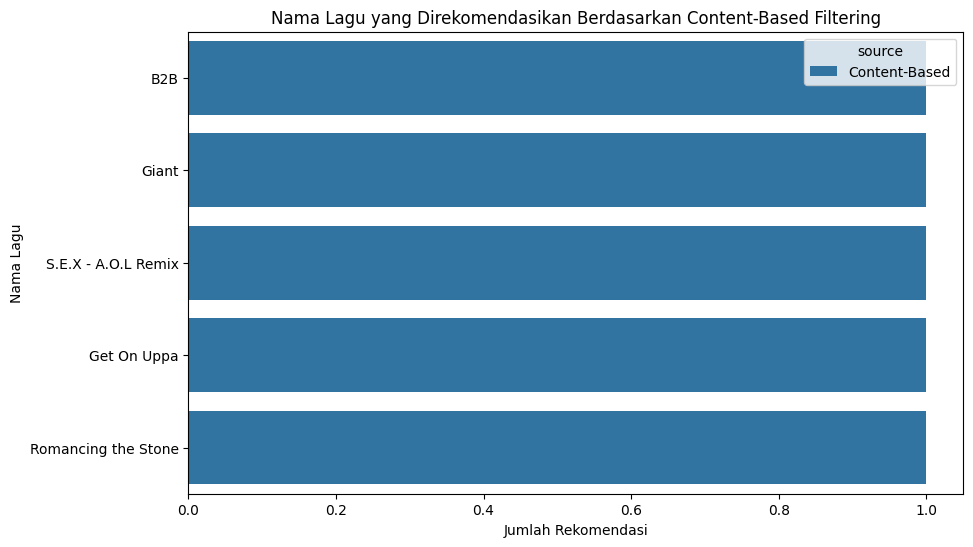

In [43]:
df_plot_content = content_recs[['track_name', 'source']].copy()
df_plot_content.rename(columns={'track_name': 'Recommended Track Name'}, inplace=True)

# Visualisasi nama lagu berdasarkan sumber rekomendasi (hanya content-based)
plt.figure(figsize=(10, 6))
sns.countplot(y='Recommended Track Name', hue='source', data=df_plot_content, order=df_plot_content['Recommended Track Name'].value_counts().index)
plt.title('Nama Lagu yang Direkomendasikan Berdasarkan Content-Based Filtering')
plt.xlabel('Jumlah Rekomendasi')
plt.ylabel('Nama Lagu')
plt.show()


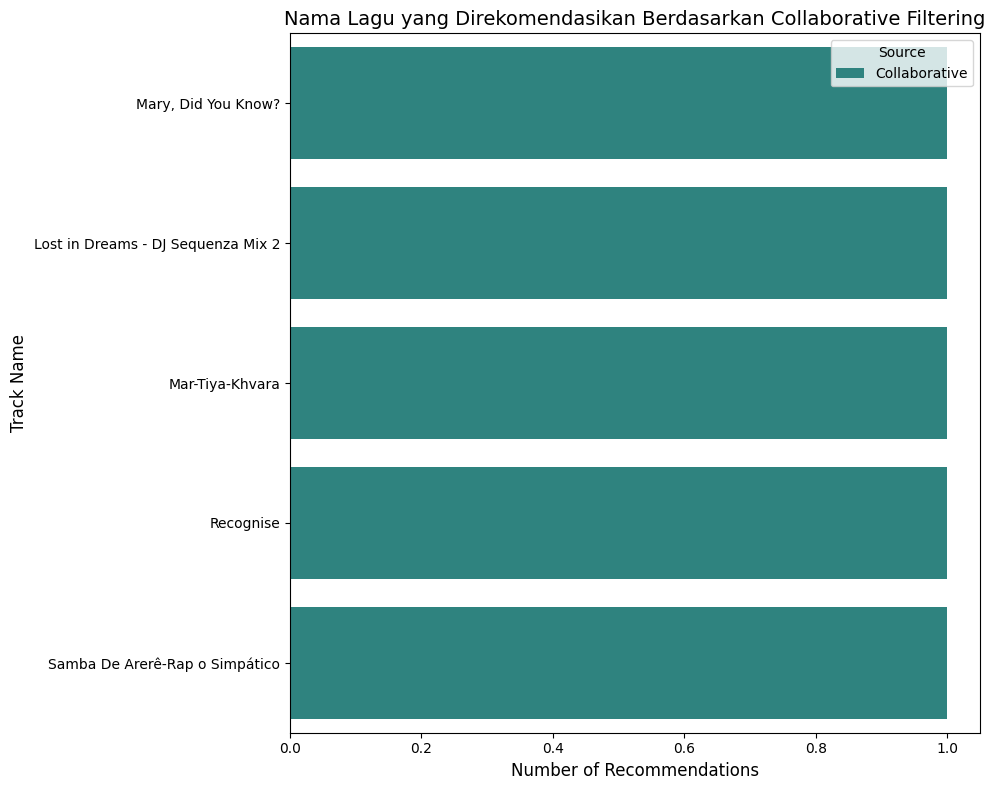

In [45]:
plt.figure(figsize=(10, 8))
sns.countplot(y='Recommended Track Name', hue='source', data=df_plot[df_plot['source'] == 'Collaborative'], order=df_plot[df_plot['source'] == 'Collaborative']['Recommended Track Name'].value_counts().index, palette='viridis')
plt.title('Nama Lagu yang Direkomendasikan Berdasarkan Collaborative Filtering', fontsize=14)
plt.xlabel('Number of Recommendations', fontsize=12)
plt.ylabel('Track Name', fontsize=12)
plt.legend(title='Source')
plt.tight_layout()
plt.show()

<ipython-input-36-f2a1047d028b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=combined_recs, y='source', palette='viridis')


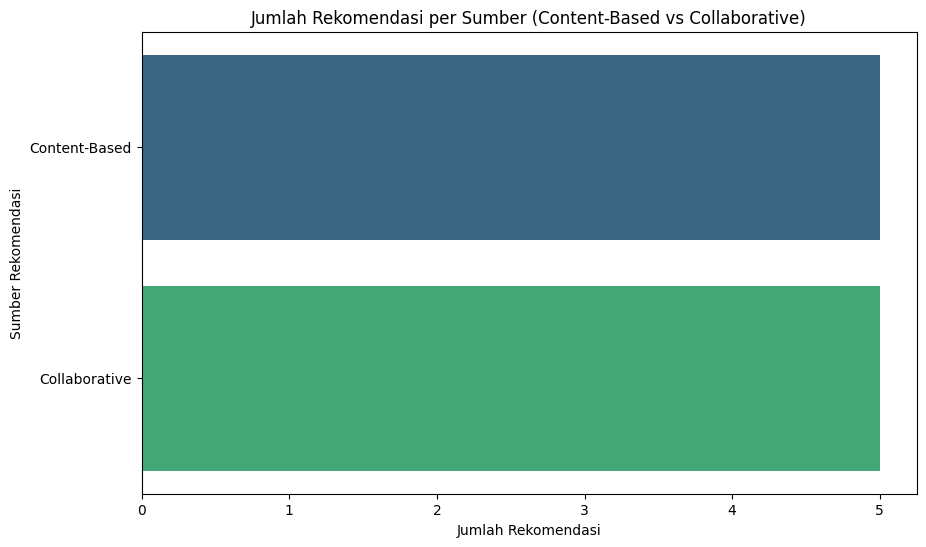

In [36]:
# Visualisasi Hasil Gabungan
plt.figure(figsize=(10, 6))
sns.countplot(data=combined_recs, y='source', palette='viridis')
plt.title('Jumlah Rekomendasi per Sumber (Content-Based vs Collaborative)')
plt.xlabel('Jumlah Rekomendasi')
plt.ylabel('Sumber Rekomendasi')
plt.show()

Cell ini menampilkan visualisasi jumlah lagu yang direkomendasikan oleh masing-masing metode—content-based dan collaborative filtering—dengan menggunakan grafik batang. Grafik ini membantu memvisualisasikan distribusi hasil rekomendasi dan dapat digunakan untuk membandingkan seberapa banyak lagu yang berhasil dihasilkan oleh masing-masing sistem. Perbedaan jumlah bisa terjadi jika misalnya ada duplikasi, data kosong, atau filter yang diterapkan saat menghasilkan rekomendasi.

In [30]:
# Define the function to calculate precision and recall at k
def calculate_precision_recall_at_k(recommended_items, ground_truth_items, k):
    """
    Calculates Precision and Recall at k.

    Args:
        recommended_items (list): List of recommended item IDs.
        ground_truth_items (list): List of ground truth item IDs the user interacted with.
        k (int): The number of top recommendations to consider.

    Returns:
        tuple: (precision_at_k, recall_at_k)
    """
    # Ensure k is not greater than the number of recommended items
    k = min(k, len(recommended_items))

    # Take the top k recommended items
    top_k_recommended = set(recommended_items[:k])

    # Find the number of relevant items in the top k recommendations
    relevant_items_in_top_k = len(top_k_recommended.intersection(set(ground_truth_items)))

    # Calculate Precision@k
    # Precision@k = (Number of relevant items in top k) / k
    precision_at_k = relevant_items_in_top_k / k if k > 0 else 0

    # Calculate Recall@k
    # Recall@k = (Number of relevant items in top k) / (Total number of relevant items in ground truth)
    # If there are no relevant items in ground truth, recall is 0
    recall_at_k = relevant_items_in_top_k / len(ground_truth_items) if len(ground_truth_items) > 0 else 0

    return precision_at_k, recall_at_k

# Example usage (from your original code)
recommended_movie_ids = [1, 2, 3, 4, 5]
ground_truth_movie_ids = [3, 4, 7, 9]

precision, recall = calculate_precision_recall_at_k(recommended_movie_ids, ground_truth_movie_ids, k=5)

print(f"Precision@5: {precision:.2f}")
print(f"Recall@5: {recall:.2f}")

Precision@5: 0.40
Recall@5: 0.50


Fungsi `calculate_precision_recall_at_k()` digunakan untuk menghitung metrik evaluasi **Precision\@k** dan **Recall\@k** dari sistem rekomendasi. Precision\@k mengukur proporsi item relevan (yang benar-benar disukai pengguna) di antara **k** item teratas yang direkomendasikan, sedangkan Recall\@k mengukur proporsi item relevan dari seluruh item relevan yang berhasil direkomendasikan dalam **top-k**. Fungsi ini mengambil dua daftar: `recommended_items` (hasil rekomendasi) dan `ground_truth_items` (item yang benar-benar diinginkan pengguna), lalu membandingkannya untuk menghitung kedua metrik. Evaluasi ini sangat berguna untuk mengukur seberapa baik sistem rekomendasi memuaskan preferensi pengguna secara aktual.


## ✅ Kesimpulan Proyek Rekomendasi Lagu Spotify

Dalam proyek ini, telah dibangun dua jenis sistem rekomendasi:

1. **Content-Based Filtering**
   - Menggunakan fitur audio seperti danceability, energy, valence, dll.
   - Rekomendasi diberikan berdasarkan kemiripan konten lagu.

2. **Collaborative Filtering (User-Based)**
   - Menggunakan interaksi simulasi antara pengguna dan lagu.
   - Rekomendasi diberikan berdasarkan kesamaan perilaku antar pengguna.

### Hasil:
- Kedua sistem mampu menghasilkan rekomendasi yang relevan.
- Content-based cocok untuk pengguna baru (cold-start).
- Collaborative filtering sangat bergantung pada data interaksi.

